                            OLS Regression Results                            
Dep. Variable:            savings_usd   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     9302.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:47:27   Log-Likelihood:            -4.3303e+05
No. Observations:               32424   AIC:                         8.661e+05
Df Residuals:                   32421   BIC:                         8.661e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  669.7714 

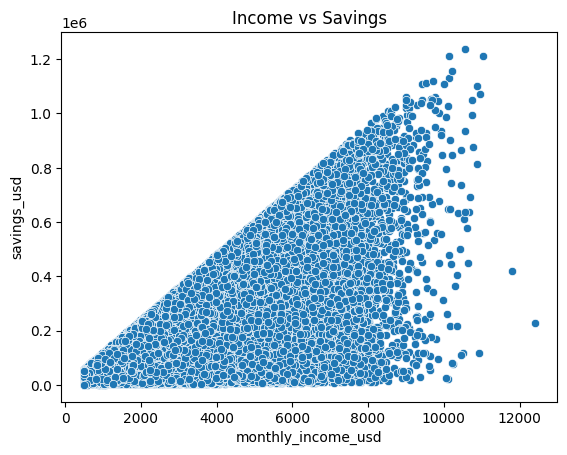

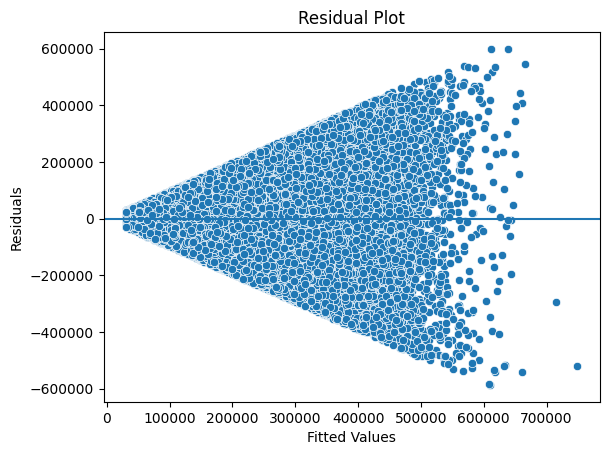

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

# Load dataset
df = pd.read_csv("synthetic_personal_finance_dataset.csv")

# Variables
X = df[['monthly_income_usd', 'monthly_expenses_usd']]
y = df['savings_usd']

# Add constant
X = sm.add_constant(X)

# Regression model
model = sm.OLS(y, X).fit()

print(model.summary())

# Spearman correlation
corr, p_value = spearmanr(df['monthly_income_usd'], df['savings_usd'])
print("Spearman correlation:", corr)
print("p-value:", p_value)

# Scatter plot
sns.scatterplot(x='monthly_income_usd', y='savings_usd', data=df)
plt.title("Income vs Savings")
plt.show()

# Residual plot
residuals = model.resid
sns.scatterplot(x=model.fittedvalues, y=residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()